In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

df = pd.read_parquet('../data/interim/master.parquet')

In [20]:
df.head()

,user_id,movie_id,rating,timestamp,title,unknown,Action,Adventure,Animation,Children,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,age,gender,occupation,zip_code
0,196,242,3,881250949,Kolya (1996),0,0,0,0,0,...,0,0,0,0,0,0,49,M,writer,55105
1,186,302,3,891717742,L.A. Confidential (1997),0,0,0,0,0,...,1,0,0,1,0,0,39,F,executive,00000
2,22,377,1,878887116,Heavyweights (1994),0,0,0,0,1,...,0,0,0,0,0,0,25,M,writer,40206
3,244,51,2,880606923,Legends of the Fall (1994),0,0,0,0,0,...,0,1,0,0,1,1,28,M,technician,80525
4,166,346,1,886397596,Jackie Brown (1997),0,0,0,0,0,...,0,0,0,0,0,0,47,M,educator,55113


### movie statistics table

In [4]:
movie_stats=df.groupby('title').agg(
    avg_rating=('rating','mean'),
    num_ratings=('rating','count')
)

In [5]:
movie_stats.head()

,avg_rating,num_ratings
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


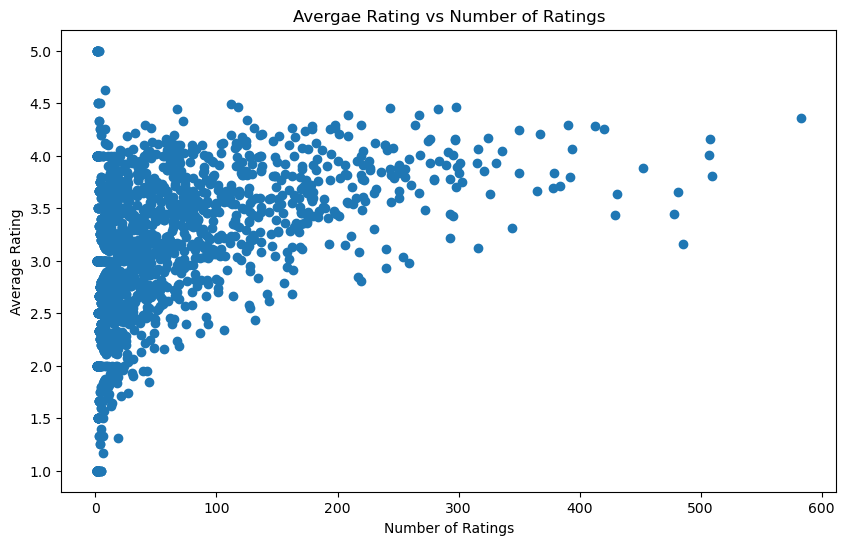

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(
    movie_stats['num_ratings'],
    movie_stats['avg_rating']
)

plt.xlabel("Number of Ratings")
plt.ylabel('Average Rating')
plt.title('Avergae Rating vs Number of Ratings')
plt.show()

### Ratings per movie distribution

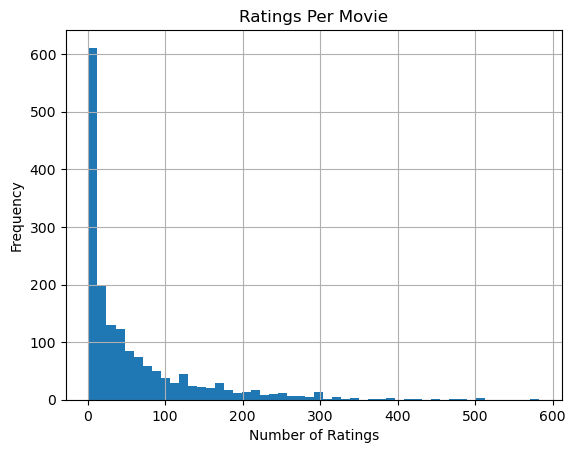

In [7]:
ratings_per_movie=df.groupby('movie_id')['rating'].count()

ratings_per_movie.hist(bins=50)
plt.title("Ratings Per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Frequency")
plt.show()

## User Item MAtrix

In [8]:
user_movie_matrix=df.pivot_table(
    index='user_id',
    columns='title',
    values='rating'
)

In [9]:
user_movie_matrix

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
user_movie_matrix.shape

# we will use this matrix later in collaborative filtering

(943, 1664)

In [11]:
#sparsity analysis

sparsity = (
    1 -
    user_movie_matrix.count().sum()
    /
    (user_movie_matrix.shape[0] *
     user_movie_matrix.shape[1])
) * 100

print(f"Sparsity: {sparsity:.2f}%")

Sparsity: 93.65%


In [15]:
filled = user_movie_matrix.notnull().sum().sum()

total = (
    user_movie_matrix.shape[0] *
    user_movie_matrix.shape[1]
)

missing = total - filled

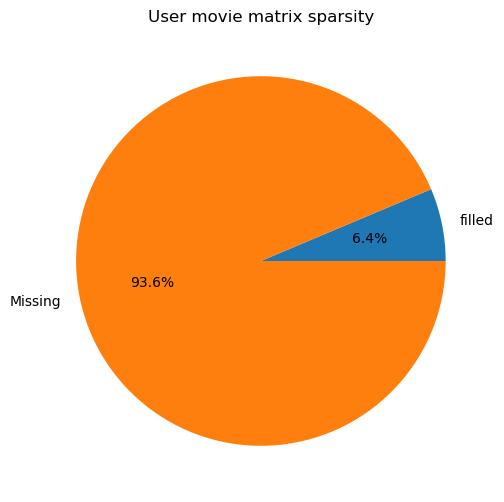

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.pie(
    [filled,missing],
    labels=['filled','Missing'],
    autopct='%1.1f%%'
)

plt.title('User movie matrix sparsity')
plt.show()

so we can conclude that not all users have watched every movie

## Movie rating Variance

In [24]:
movie_variance=df.groupby('title')['rating'].std()

movie_variance.sort_values(ascending=False).head()

title
Delta of Venus (1994)      2.828427
Tough and Deadly (1995)    2.828427
The Deadly Cure (1996)     2.828427
Hugo Pool (1997)           2.138090
American Dream (1990)      2.121320
Name: rating, dtype: float64

In [ ]:
#high variance means mixed opinions

### Correlation b/w popularity and rating



In [25]:
movie_stats.corr()

,avg_rating,num_ratings
avg_rating,1.000000,0.430998
num_ratings,0.430998,1.000000


<Axes: xlabel='num_ratings', ylabel='avg_rating'>

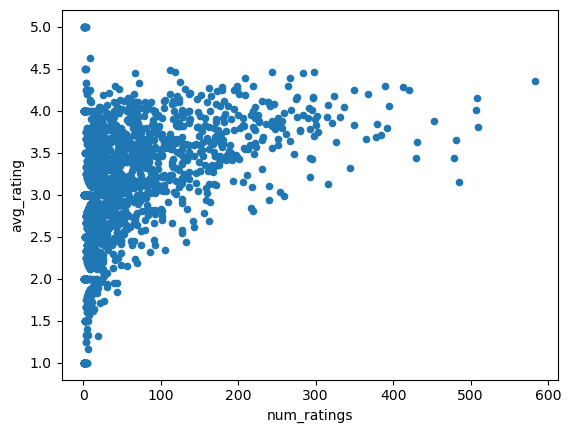

In [26]:
movie_stats.plot.scatter(
    x='num_ratings',
    y='avg_rating'
)

# Top 10 movies worth recommending

In [27]:
movie_stats[
    movie_stats['num_ratings']>100
].sort_values('avg_rating',ascending=False).head(10)

,avg_rating,num_ratings
title,,
"Close Shave, A (1995)",4.491071,112
Schindler's List (1993),4.466443,298
"Wrong Trousers, The (1993)",4.466102,118
Casablanca (1942),4.456790,243
"Shawshank Redemption, The (1994)",4.445230,283
Rear Window (1954),4.387560,209
"Usual Suspects, The (1995)",4.385768,267
Star Wars (1977),4.358491,583
12 Angry Men (1957),4.344000,125


# Key Findings

- User item matrix is highly sparse
- Most movies have very few ratings
- A small number of blockbuster movies dominates ratings
- User Activity varies significantly
- Avg rating alone is misleading without rating count
- Collaborative filtering may suffer form spasrsity

### saving user item matrix for collaborative filtering in future

In [28]:
user_movie_matrix.to_parquet(
    '../data/processed/user_movie_matrix.parquet'
)

print('Saved')

Saved
